In [ ]:
from scipy.io.arff import loadarff
import numpy as np
import pandas as pd

In [ ]:
data, meta = loadarff('/content/supermarket.arff')

In [ ]:
data_np = np.array(data)
df = pd.DataFrame(data_np, dtype=str)
df

,department1,department2,department3,department4,department5,department6,department7,department8,department9,grocery misc,...,department208,department209,department210,department211,department212,department213,department214,department215,department216,total
0,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
1,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
2,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
3,t,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4622,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4623,?,?,?,t,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,high
4624,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low
4625,?,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


In [ ]:
supermarket_com_nans = df.replace('?', np.nan) #troca todos os '?' por NaN (valor vazio que o Pandas entende)

df_limpo = supermarket_com_nans.dropna(axis=1, how='all') #remove colunas inteiras que estão 100% vazias
df_limpo = df_limpo.fillna('?') #voltar os NaN pra '?'

colunas_remover = df_limpo.filter(regex=r'department\d+').columns #department+numero e salva
#print(colunas_remover)
df_limpo = df_limpo.drop(columns=colunas_remover) #remove essas colunas salvas do df


df_limpo.head() #mostra as priemiras linhas

/tmp/ipykernel_51023/166570646.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  supermarket_com_nans = df.replace('?', np.nan) #troca todos os '?' por NaN (valor vazio que o Pandas entende)


,grocery misc,baby needs,bread and cake,baking needs,juice-sat-cord-ms,tea,biscuits,canned fish-meat,canned fruit,canned vegetables,...,casks red wine,750ml white nz,750ml red nz,750ml white imp,750ml red imp,sparkling nz,sparkling imp,port and sherry,non host support,total
0,?,t,t,t,t,?,t,?,?,t,...,?,t,?,?,?,?,?,?,?,high
1,?,?,?,?,?,?,?,t,t,t,...,?,?,?,?,?,?,?,?,?,low
2,?,?,t,t,t,?,t,?,t,?,...,?,?,?,?,?,?,?,?,?,low
3,?,?,t,t,t,?,t,?,?,t,...,?,?,?,?,?,?,?,?,?,low
4,?,?,t,t,t,t,?,?,?,?,...,?,?,?,?,?,?,?,?,?,low


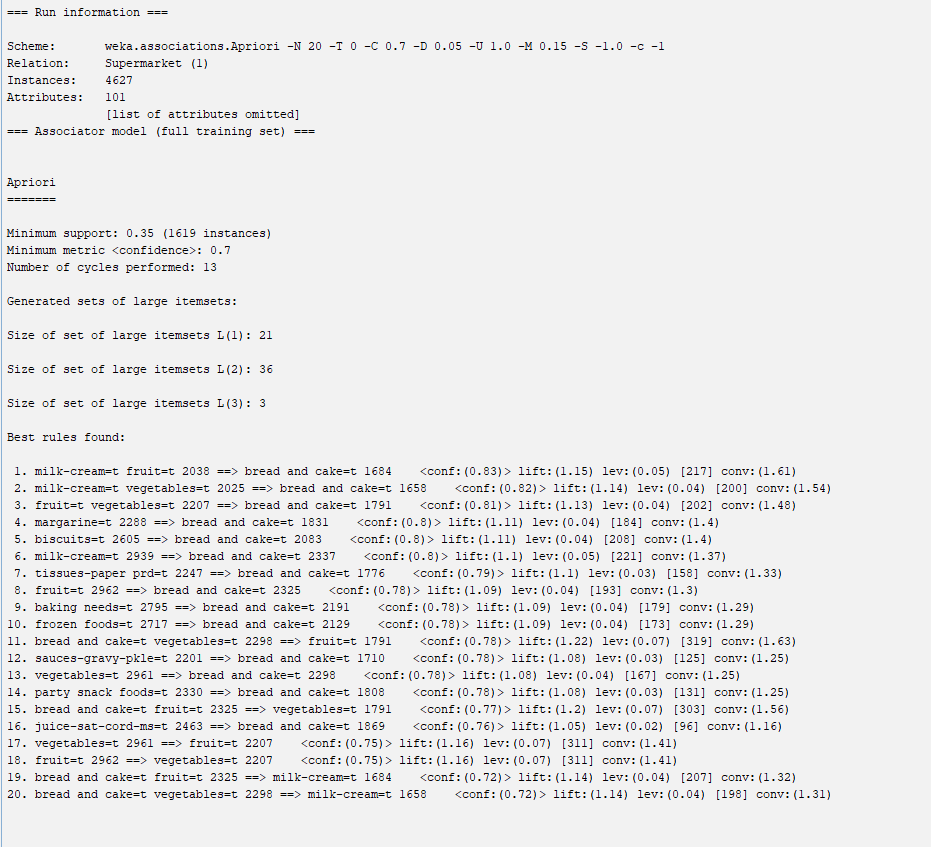
## **Célula 2 — explicação das métricas**
## Métricas utilizadas

**Suporte:** frequência com que os itens da regra aparecem juntos nas transações.
Fórmula: suporte(A → B) = transações com A e B / total de transações
ou
suporte(A, B ⇒ C) = transações com A, B e C / total de transações

**Confiança:** das vezes que A aparece, quantas vezes B também aparece.
Fórmula: confiança(A → B) = suporte(A e B) / suporte(A)
ou
confiança(A, B ⇒ C) = transações com A, B e C / transações com A e B

**Lift:** mede o quanto a regra é melhor do que o acaso. Lift > 1 indica associação real.
Fórmula: lift(A → B) = confiança(A → B) / suporte(B)
ou
lift(A, B ⇒ C) = confiança(A, B ⇒ C) / suporte(C)

**Leverage:** diferença entre a co-ocorrência real e a esperada pelo acaso.
Ao contrário do lift (que é uma razão), o leverage é uma diferença absoluta.
Leverage = 0 indica independência. Quanto maior, mais forte a associação.
Fórmula: leverage(A → B) = suporte(A e B) − suporte(A) × suporte(B)
ou
leverage(A, B ⇒ C) = suporte(A, B e C) − suporte(A, B) × suporte(C)

## **Célula 1 — Título e introdução**
  # Regras de Associação — Apriori

  ## Configuração utilizada no Weka
  - Algoritmo: Apriori
  - Suporte mínimo: 0.35
  - Confiança mínima: 0.7
  - Número de regras: 20
  - Total de instâncias: 4627
  - Total de atributos após limpeza: 101

## **Célula 3 — Regra 1**
## Regra 1: milk-cream + fruit → bread and cake

**Regra:** {milk-cream, fruit} ==> {bread and cake}

**Métricas:**
- Suporte: 1684 / 4627 = 0.36 (36% das compras contêm os 3 itens juntos)
- Confiança: 0.83 (83% de quem compra leite/creme e fruta também compra pão/bolo)
- Lift: 1.15 (a combinação ocorre 15% mais do que seria esperado pelo acaso)
- Leverage: 0.05 (5% a mais de co-ocorrência real em relação ao esperado)

**Cenário:**
Clientes que compram leite/creme e frutas estão montando um café da manhã completo.
Pão e bolo são itens naturais dessa cesta — quem já pegou leite e fruta provavelmente
está pensando numa refeição matinal. Esse padrão é comum em famílias com crianças
ou pessoas com rotina de café da manhã em casa.

**Intervenção:**
O supermercado pode divulgar para fazerem cadastro da loja, para o cliente cadastrado levar os itens de café da manhã com promoção, o cadastro em loja cria uma vantagem porque muda a relação do cliente com o lugar: Aumenta a chance de deixar de ser uma compra totalmente livre e exporádica e o cliente passar a ter sentimento de vínculo e benefício associado.

## **Célula 4 — Regra 11**
## Regra 2: bread and cake + vegetables → fruit

**Regra:** {bread and cake, vegetables} ==> {fruit}

**Métricas:**
- Suporte: 1791 / 4627 = 0.39 (39% das compras contêm os 3 itens juntos)
- Confiança: 0.78 (78% de quem compra pão/bolo e vegetais também compra fruta)
- Lift: 1.22 (maior lift das 3 regras — ocorre 22% mais do que o acaso esperaria)
- Leverage: 0.07 (maior leverage das 3 — 7% a mais de co-ocorrência real)

**Cenário:**
Esta é a regra mais forte das três, com maior lift e leverage. Clientes que compram
pão e vegetais estão fazendo uma compra voltada para alimentação saudável e equilibrada.
A fruta entra como complemento natural — são clientes preocupados com saúde ou que
têm hábito de consumir frutas junto com refeições e lanches.

**Intervenção:**
Criar displays ou ilhas temáticas de "alimentação saudável" reunindo frutas, vegetais
e pães integrais. O mercado pode oferecer kits/cestas promocionais com esses itens juntos,
ou usar cartazes como "quem compra isso também leva fruta" próximo à seção de vegetais.

## **Célula 5 — Regra 10**
## Regra 10: frozen foods ⇒ bread and cake

**Regra:** {frozen foods} ⇒ {bread and cake}

**Métricas:**
- Suporte: 2129 / 4627 = 0.46 (46% das compras têm frozen foods + bread and cake juntos)
- Confiança: 0.78 (Quem compra congelados tem 78% de chance de levar pão e bolo)
- Lift: 1.09 (A associação ocorre 9% acima do acaso)
- Leverage: 0.04 (4% na co-ocorrência real)

**Cenário:**
Clientes que compram frozen foods geralmente estão realizando compras voltadas à praticidade, priorizando itens rápidos de preparar ou já prontos para consumo. Nesse contexto, bread and cake aparece como um complemento natural, pois são alimentos que também exigem pouco ou nenhum preparo e podem ser consumidos imediatamente. Isso indica um padrão de comportamento em que o consumidor busca conveniência e economia de tempo no dia a dia, combinando produtos que facilitam a rotina alimentar. Não se trata necessariamente de uma relação direta entre os itens, mas de um tipo de missão de compra focada em rapidez e facilidade, onde diferentes categorias de produtos cumprem o mesmo objetivo de simplificar o consumo.

**Intervenção:**
Organizar o layout da loja criando zonas de conveniência, aproximando os setores de congelados e padaria para estimular compras conjuntas.
Também é possível enviar notificação no app do mercado sugerindo pão e bolo quando o
cliente escaneia comidas congeladas.